# From fermions to qubits: the Jordan-Wigner transformation

Executable companion to the last section of chapter 3 and to the
qubit-encoding section of chapter 4.

A quantum computer acts on qubits, not on fermionic Fock states.  The
occupation-number basis is already binary, so the *states* map across
trivially,

$$
|n_0 n_1\cdots n_{M-1}\rangle_{\rm Fock}
\;\longleftrightarrow\;
|n_0 n_1\cdots n_{M-1}\rangle_{\rm qubit},
$$

and all the work is in the *operators*: the fermionic minus signs have to be
reproduced by something.  The Jordan-Wigner transformation supplies them with
a string of Pauli $Z$'s,

$$
a_p^\dagger = \left(\prod_{j<p} Z_j\right)\frac{X_p - iY_p}{2},
\qquad
a_p = \left(\prod_{j<p} Z_j\right)\frac{X_p + iY_p}{2}.
$$

Everything below is done with explicit matrices, so nothing has to be taken
on trust.

In [1]:
import sys, os, glob
# the chapter programs live in BookPrograms/chapterNN; put them all on the path
for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                        "BookPrograms", "chapter*"))):
    if _d not in sys.path:
        sys.path.insert(0, _d)

from itertools import product

import numpy as np

I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}


def kron(matrices):
    out = np.array([[1.0 + 0j]])
    for matrix in matrices:
        out = np.kron(out, matrix)
    return out


def pauli_string(label):
    return kron([PAULI[c] for c in label])


def single(op, site, n_qubits):
    return kron([op if k == site else I2 for k in range(n_qubits)])


def decompose(matrix, tol=1e-10):
    """H = sum_P c_P P with c_P = Tr(P H)/2^M -- exact, by orthogonality."""
    dim = matrix.shape[0]
    n_qubits = int(round(np.log2(dim)))
    out = {}
    for word in product("IXYZ", repeat=n_qubits):
        label = "".join(word)
        c = np.trace(pauli_string(label) @ matrix) / dim
        if abs(c) > tol:
            out[label] = float(c.real) if abs(c.imag) < tol else complex(c)
    return out


def show(d, indent="   "):
    for label, c in sorted(d.items(), key=lambda kv: (-abs(kv[1]), kv[0])):
        print(f"{indent}{c:+.6f}  {label}")


def weight(label):
    return sum(1 for c in label if c != "I")

In [2]:
class JordanWigner:
    """Fermion operators on n modes, as 2^n x 2^n qubit matrices."""

    def __init__(self, n_modes):
        self.n = n_modes
        self.dim = 1 << n_modes

    def _string(self, p):
        return kron([Z if k < p else I2 for k in range(self.n)])

    def create(self, p):
        return self._string(p) @ single((X - 1j*Y)/2.0, p, self.n)

    def annihilate(self, p):
        return self.create(p).conj().T

    def number(self, p):
        return self.create(p) @ self.annihilate(p)

    def identity(self):
        return np.eye(self.dim, dtype=complex)

    def term(self, coefficient, creators, annihilators):
        out = coefficient * self.identity()
        for p in creators:
            out = out @ self.create(p)
        for p in annihilators:
            out = out @ self.annihilate(p)
        return out

    def anticommutator_errors(self):
        worst, eye = 0.0, self.identity()
        for p in range(self.n):
            for q in range(self.n):
                a_p, a_q, c_p, c_q = (self.annihilate(p), self.annihilate(q),
                                      self.create(p), self.create(q))
                target = eye if p == q else 0.0*eye
                worst = max(worst, np.abs(a_p@c_q + c_q@a_p - target).max())
                worst = max(worst, np.abs(a_p@a_q + a_q@a_p).max())
                worst = max(worst, np.abs(c_p@c_q + c_q@c_p).max())
        return float(worst)

## 1. Is it a legal transformation?

The whole point of the parity string is to make the qubit operators
*anticommute*.  Without it they would merely commute on different sites,
which is the wrong statistics.

In [3]:
for n in (2, 3, 4, 5):
    print(f"{n} modes: max violation of the anticommutators = "
          f"{JordanWigner(n).anticommutator_errors():.1e}")

n = 3
naive = [single((X + 1j*Y)/2.0, p, n) for p in range(n)]
print("\nwithout the parity string, |{sigma_0, sigma_1}| =",
      np.abs(naive[0]@naive[1] + naive[1]@naive[0]).max(), " (should be 0)")

2 modes: max violation of the anticommutators = 0.0e+00
3 modes: max violation of the anticommutators = 0.0e+00
4 modes: max violation of the anticommutators = 0.0e+00
5 modes: max violation of the anticommutators = 0.0e+00

without the parity string, |{sigma_0, sigma_1}| = 2.0  (should be 0)


## 2. Number operators, hopping, and pairs

Three identities do all the work:

$$
\hat n_p = \frac{I-Z_p}{2},
$$
$$
a_p^\dagger a_q + a_q^\dagger a_p \;\to\;
\tfrac12\left(X_pZ\cdots ZX_q + Y_pZ\cdots ZY_q\right),
$$
$$
a_p^\dagger a_q^\dagger + a_q a_p \;\to\;
\tfrac12\left(X_pZ\cdots ZX_q - Y_pZ\cdots ZY_q\right).
$$

The last two differ only in one sign — that single sign is the difference
between transporting a particle and creating a pair.

In [4]:
jw = JordanWigner(4)

print("n_p:")
for p in range(4):
    print("  ", decompose(jw.number(p)))

print("\nhopping  a^+_p a_q + a^+_q a_p:")
for p, q in ((0, 1), (0, 2), (0, 3)):
    print(f"  (p, q) = ({p}, {q}):")
    show(decompose(jw.create(p)@jw.annihilate(q)
                   + jw.create(q)@jw.annihilate(p)), "     ")

print("\npair  a^+_p a^+_q + a_q a_p:")
for p, q in ((0, 1), (0, 3)):
    print(f"  (p, q) = ({p}, {q}):")
    show(decompose(jw.create(p)@jw.create(q)
                   + jw.annihilate(q)@jw.annihilate(p)), "     ")

n_p:
   {'IIII': 0.5, 'ZIII': -0.5}
   {'IIII': 0.5, 'IZII': -0.5}
   {'IIII': 0.5, 'IIZI': -0.5}
   {'IIII': 0.5, 'IIIZ': -0.5}

hopping  a^+_p a_q + a^+_q a_p:
  (p, q) = (0, 1):
     +0.500000  XXII
     +0.500000  YYII
  (p, q) = (0, 2):
     +0.500000  XZXI
     +0.500000  YZYI
  (p, q) = (0, 3):
     +0.500000  XZZX
     +0.500000  YZZY

pair  a^+_p a^+_q + a_q a_p:
  (p, q) = (0, 1):
     +0.500000  XXII
     -0.500000  YYII
  (p, q) = (0, 3):
     +0.500000  XZZX
     -0.500000  YZZY


## 3. A general two-body term

With four distinct indices the Hermitian two-body term becomes eight Pauli
strings of weight four, each with coefficient $1/8$.  Read the four orbitals
as $(p_+, p_-, q_+, q_-)$ and this operator is the pair-transfer term
$P_p^\dagger P_q + {\rm h.c.}$ of the pairing model.

In [5]:
matrix = jw.term(1.0, [0, 1], [3, 2])          # a^+_0 a^+_1 a_3 a_2
hermitian = matrix + matrix.conj().T
show(decompose(hermitian))
counts = {}
for label in decompose(hermitian):
    counts[weight(label)] = counts.get(weight(label), 0) + 1
print("strings by weight:", dict(sorted(counts.items())))

   +0.125000  XXXX
   -0.125000  XXYY
   +0.125000  XYXY
   +0.125000  XYYX
   +0.125000  YXXY
   +0.125000  YXYX
   -0.125000  YYXX
   +0.125000  YYYY
strings by weight: {4: 8}


For a generic one- plus two-body Hamiltonian on $M$ modes the number of
distinct Pauli strings grows as $O(M^4)$, and the longest of them span the
whole register because of the parity chains.

In [6]:
def one_body(jw, h):
    out = np.zeros((jw.dim, jw.dim), dtype=complex)
    for p in range(jw.n):
        for q in range(jw.n):
            out += h[p, q] * jw.create(p) @ jw.annihilate(q)
    return out


def two_body(jw, v):
    out = np.zeros((jw.dim, jw.dim), dtype=complex)
    for p, q, r, s in product(range(jw.n), repeat=4):
        if v[p, q, r, s] != 0.0:
            out += 0.25*v[p, q, r, s] * (jw.create(p) @ jw.create(q)
                                         @ jw.annihilate(s) @ jw.annihilate(r))
    return out


rng = np.random.default_rng(11)
print(f"{'M':>4s} {'4^M':>8s} {'strings':>9s} {'max weight':>12s}")
for M in (2, 3, 4, 5, 6):
    jw_m = JordanWigner(M)
    h = rng.normal(size=(M, M)); h = h + h.T
    v = rng.normal(size=(M,)*4)
    v = v - v.transpose(1, 0, 2, 3)
    v = v - v.transpose(0, 1, 3, 2)
    v = v + v.transpose(2, 3, 0, 1)
    d = decompose(one_body(jw_m, h) + two_body(jw_m, v))
    print(f"{M:4d} {4**M:8d} {len(d):9d} "
          f"{max(weight(k) for k in d):12d}")

   M      4^M   strings   max weight
   2       16         6            2


   3       64        19            3


   4      256        55            4


   5     1024       136            5


   6     4096       292            6


## 4. The pairing model, two ways

Order the spin-orbitals so the two partners of a level are adjacent,
$(1_+, 1_-, 2_+, 2_-, \dots)$.  With $L$ levels that is $2L$ qubits.

In [7]:
def pairing_full_space(levels, g, xi=1.0):
    jw = JordanWigner(2*levels)
    H = np.zeros((jw.dim, jw.dim), dtype=complex)
    for p in range(1, levels+1):
        for spin in (0, 1):
            H += xi*(p-1) * jw.number(2*(p-1) + spin)
    for p in range(1, levels+1):
        for q in range(1, levels+1):
            H += jw.term(-0.5*g, [2*(p-1), 2*(p-1)+1],
                         [2*(q-1)+1, 2*(q-1)])
    return H


def pairing_ph_full_space(levels, g, f, xi=1.0):
    jw = JordanWigner(2*levels)
    H = pairing_full_space(levels, g, xi)
    for p in range(1, levels+1):
        for q in range(1, levels+1):
            for r in range(1, levels+1):
                block = jw.term(-0.5*f, [2*(p-1), 2*(p-1)+1],
                                [2*(q-1)+1, 2*(r-1)])
                H += block + block.conj().T
    return H


H_full = pairing_full_space(2, g=1.0)
d = decompose(H_full)
print(f"L = 2 -> 4 qubits, {len(d)} Pauli strings:")
show(d)

L = 2 -> 4 qubits, 15 Pauli strings:
   +0.750000  IIII
   -0.375000  IIIZ
   -0.375000  IIZI
   -0.125000  IIZZ
   +0.125000  IZII
   +0.125000  ZIII
   -0.125000  ZZII
   -0.062500  XXXX
   +0.062500  XXYY
   -0.062500  XYXY
   -0.062500  XYYX
   -0.062500  YXXY
   -0.062500  YXYX
   +0.062500  YYXX
   -0.062500  YYYY


In the seniority-zero space a level is either empty or holds a complete pair,
so its state is one bit and not two.  With the local quasispin operators
$S_p^+ = P_p^\dagger$, $S_p^z = (N_p-1)/2$ identified as
$S_p^+ = (X_p - iY_p)/2$ and $N_p = I - Z_p$, the Hamiltonian collapses to

$$
\hat H = \sum_{p=1}^{L}\left[\xi(p-1)-\frac{g}{4}\right](I - Z_p)
  - \frac{g}{4}\sum_{p<q}\left(X_pX_q + Y_pY_q\right)
$$

on $L$ qubits: an $XY$ model with infinite-range couplings in an
inhomogeneous field.

In [8]:
def pairing_pair_qubits(levels, g, xi=1.0):
    dim = 1 << levels
    H = np.zeros((dim, dim), dtype=complex)
    plus = [single((X - 1j*Y)/2.0, p, levels) for p in range(levels)]
    minus = [single((X + 1j*Y)/2.0, p, levels) for p in range(levels)]
    number = [np.eye(dim, dtype=complex) - single(Z, p, levels)
              for p in range(levels)]
    for p in range(levels):
        H += xi*p*number[p]
        for q in range(levels):
            H += -0.5*g * plus[p] @ minus[q]
    return H


def closed_form(levels, g, xi=1.0):
    out = {}

    def add(label, value):
        out[label] = out.get(label, 0.0) + value

    for p in range(levels):
        c = xi*p - 0.25*g
        add("I"*levels, c)
        add("".join("Z" if k == p else "I" for k in range(levels)), -c)
    for p in range(levels):
        for q in range(p+1, levels):
            for letter in "XY":
                add("".join(letter if k in (p, q) else "I"
                            for k in range(levels)), -0.25*g)
    return {k: v for k, v in out.items() if abs(v) > 1e-12}


H_pair = pairing_pair_qubits(2, g=1.0)
d = decompose(H_pair)
print(f"L = 2 -> 2 qubits, {len(d)} Pauli strings:")
show(d)
for L in (2, 3, 4):
    predicted, computed = closed_form(L, 1.0), decompose(pairing_pair_qubits(L, 1.0))
    ok = (set(predicted) == set(computed)
          and all(abs(predicted[k]-computed[k]) < 1e-10 for k in predicted))
    print(f"   L = {L}: closed form reproduces the decomposition: {ok}")

L = 2 -> 2 qubits, 5 Pauli strings:
   -0.750000  IZ
   +0.500000  II
   -0.250000  XX
   -0.250000  YY
   +0.250000  ZI
   L = 2: closed form reproduces the decomposition: True
   L = 3: closed form reproduces the decomposition: True
   L = 4: closed form reproduces the decomposition: True


The compact encoding is a **restriction, not an approximation**: its spectrum
is exactly the seniority-zero part of the full one, at fixed particle number.

In [9]:
def seniority_zero_indices(levels):
    keep = []
    for state in range(1 << (2*levels)):
        if all(((state >> (2*p)) & 1) == ((state >> (2*p+1)) & 1)
               for p in range(levels)):
            keep.append(state)
    return keep


def particle_number(n_modes):
    return np.array([bin(s).count("1") for s in range(1 << n_modes)])


for levels in (2, 3):
    H_full = pairing_full_space(levels, g=1.0)
    H_pair = pairing_pair_qubits(levels, g=1.0)
    keep, occ = seniority_zero_indices(levels), particle_number(2*levels)
    for pairs in range(1, levels+1):
        rows = [k for k in keep if occ[k] == 2*pairs]
        a = np.sort(np.linalg.eigvalsh(H_full[np.ix_(rows, rows)]).real)
        pr = [k for k in range(1 << levels) if bin(k).count("1") == pairs]
        b = np.sort(np.linalg.eigvalsh(H_pair[np.ix_(pr, pr)]).real)
        print(f"L = {levels}, {pairs} pair(s): {len(rows):3d} states, "
              f"agree: {np.allclose(a, b)},  E_0 = {a[0]:.8f}")

L = 2, 1 pair(s):   2 states, agree: True,  E_0 = -0.61803399
L = 2, 2 pair(s):   1 states, agree: True,  E_0 = 1.00000000
L = 3, 1 pair(s):   3 states, agree: True,  E_0 = -0.70530340
L = 3, 2 pair(s):   3 states, agree: True,  E_0 = 0.79469660
L = 3, 3 pair(s):   1 states, agree: True,  E_0 = 4.50000000


## 5. What the particle-hole term costs

The particle-hole term breaks pairs, so the seniority-zero space is no longer
invariant and the one-qubit-per-level encoding is not available at all.  The
leakage out of that space is exactly $f/2$, the $1p$–$1h$ matrix element of
chapter 4.

In [10]:
levels = 2
for f in (0.0, 0.1):
    H = pairing_ph_full_space(levels, g=1.0, f=f)
    d = decompose(H)
    counts = {}
    for label in d:
        counts[weight(label)] = counts.get(weight(label), 0) + 1
    keep, occ = seniority_zero_indices(levels), particle_number(2*levels)
    rows = [k for k in keep if occ[k] == 2]
    others = [k for k in range(1 << (2*levels))
              if occ[k] == 2 and k not in rows]
    print(f"f = {f}: {len(d):3d} Pauli strings, weights "
          f"{dict(sorted(counts.items()))}")
    print(f"        largest element out of the seniority-zero space: "
          f"{np.abs(H[np.ix_(others, rows)]).max():.4f}")

print()
print(f"{'model':>22s} {'qubits':>8s} {'strings':>9s} {'max weight':>12s}")
for levels in (2, 3):
    for name, matrix in (("pairing, pair qubits",
                          pairing_pair_qubits(levels, g=1.0)),
                         ("pairing, full space",
                          pairing_full_space(levels, g=1.0)),
                         ("pairing + p-h, full",
                          pairing_ph_full_space(levels, g=1.0, f=0.1))):
        d = decompose(matrix)
        n_qubits = int(round(np.log2(matrix.shape[0])))
        print(f"{name:>22s} {n_qubits:8d} {len(d):9d} "
              f"{max(weight(k) for k in d):12d}")

f = 0.0:  15 Pauli strings, weights {0: 1, 1: 4, 2: 2, 4: 8}
        largest element out of the seniority-zero space: 0.0000
f = 0.1:  27 Pauli strings, weights {0: 1, 1: 4, 2: 6, 3: 4, 4: 12}
        largest element out of the seniority-zero space: 0.0500

                 model   qubits   strings   max weight


  pairing, pair qubits        2         5            2
   pairing, full space        4        15            4
   pairing + p-h, full        4        27            4


  pairing, pair qubits        3        10            2


   pairing, full space        6        34            4


   pairing + p-h, full        6       118            6


## 6. Nothing is lost in translation

The qubit Hamiltonian is the same operator written differently, so it has to
give the energies of chapter 4 exactly.  $L=4$, $N=4$, $g=1$, in the
$S_z = 0$ sector:

In [11]:
def two_sz(levels):
    out = []
    for state in range(1 << (2*levels)):
        up = sum((state >> (2*p)) & 1 for p in range(levels))
        dn = sum((state >> (2*p+1)) & 1 for p in range(levels))
        out.append(up - dn)
    return np.array(out)


occ, spin = particle_number(8), two_sz(4)
rows = [k for k in range(256) if occ[k] == 4 and spin[k] == 0]
reference = {0.0: 0.63554847, 0.05: 0.45058234,
             0.20: -0.18348455, 0.50: -1.69173670}

print(f"{'f':>6s} {'dim':>5s} {'E_0 (Jordan-Wigner)':>21s} {'chapter 4':>14s}")
for f, expected in reference.items():
    H = pairing_ph_full_space(4, g=1.0, f=f)
    E = np.sort(np.linalg.eigvalsh(H[np.ix_(rows, rows)]).real)
    print(f"{f:6.2f} {len(rows):5d} {E[0]:21.8f} {expected:14.8f}")

     f   dim   E_0 (Jordan-Wigner)      chapter 4


  0.00    36            0.63554847     0.63554847


  0.05    36            0.45058234     0.45058234


  0.20    36           -0.18348455    -0.18348455


  0.50    36           -1.69173670    -1.69173670


## Where this leads

Equation $\hat H = \sum_\alpha h_\alpha P_\alpha$ is the input to essentially
every quantum algorithm for many-body systems.

- In the **variational quantum eigensolver** the energy is obtained by
  measuring each Pauli string separately and adding the results with their
  weights, so the number of strings is the number of measurements.
- In a **Trotterised time evolution** each string contributes one factor
  $\exp(-i h_\alpha P_\alpha \Delta t)$ to the circuit, so the number of
  strings is the circuit depth and the weight of each is its entangling cost.

Both counts are what the tables above are really about, and both are the
reason it pays to exploit a symmetry — the seniority here — *before* choosing
an encoding rather than after.

## The weight spectrum of the pairing Hamiltonian

Since the number of Pauli strings and their weights are what a quantum
algorithm has to pay for, it is worth looking at the whole distribution rather
than at the two summary numbers of the tables above.  The figure below counts
the strings of the Jordan-Wigner transformed pairing Hamiltonian by weight,
for one, two and three levels in the full $2L$-qubit encoding.  We take the
decomposition straight from the program, so every coefficient is obtained by
the exact trace $c_P = {\rm Tr}(PH)/2^M$; that costs $4^M$ traces, which is
why we stop at six qubits.

The shape is the same in every case and it is easy to account for.  There is
always the single identity string, which carries the constant part of the
Hamiltonian.  The $2L$ strings of weight one are the $Z_p$'s coming from the
single-particle energies and from the diagonal part of the pairing
interaction, and the $L$ strings of weight two are the $Z_pZ_q$'s produced by
the $p=q$ pair-transfer terms.  Everything else has weight four: each of the
$L(L-1)/2$ pairs of distinct levels contributes eight strings such as $XXXX$
and $XXYY$, and those weight-four strings quickly dominate the count.
There is nothing of weight three, because the pair-transfer operator always
moves two particles at a time and touches four spin-orbitals at once.

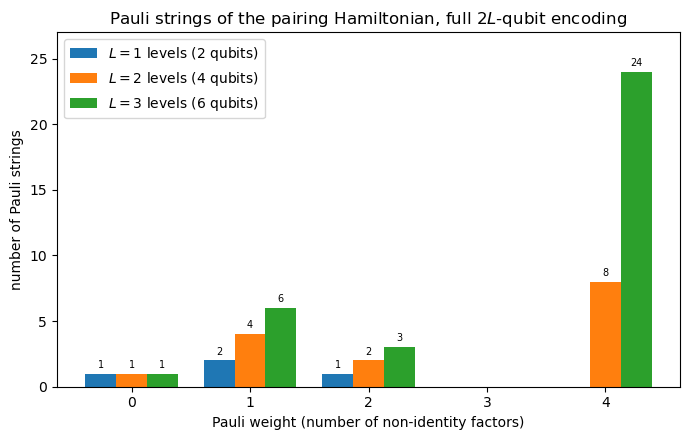

In [12]:
import matplotlib.pyplot as plt

import jordanwigner

full_levels = (1, 2, 3)
full_decompositions = {
    L: jordanwigner.decompose(jordanwigner.pairing_full_space(L, g=1.0))
    for L in full_levels
}

weights = list(range(5))
width = 0.26

fig, ax = plt.subplots(figsize=(7, 4.5))
for position, L in enumerate(full_levels):
    counts = [sum(1 for label in full_decompositions[L]
                  if jordanwigner.weight(label) == w) for w in weights]
    ax.bar([w + (position - 1) * width for w in weights], counts, width,
           label=f"$L = {L}$ levels ({2 * L} qubits)")
    for w, count in zip(weights, counts):
        if count:
            ax.text(w + (position - 1) * width, count + 0.3, str(count),
                    ha="center", va="bottom", fontsize=7)

ax.set_xlabel("Pauli weight (number of non-identity factors)")
ax.set_ylabel("number of Pauli strings")
ax.set_title("Pauli strings of the pairing Hamiltonian, "
             "full $2L$-qubit encoding")
ax.set_xticks(weights)
ax.set_ylim(0, 27)
ax.legend()
fig.tight_layout()
plt.show()


## What the seniority-zero encoding saves

The comparison that matters for a variational calculation is between the two
encodings of the same physics, and it is a comparison of three quantities at
once: how many qubits the register needs, how many Pauli strings have to be
measured, and how long the longest of those strings is.  The left panel counts
the strings against the number of levels $L$, the right panel gives the
largest weight, and the register size is in the legend.  We can push the
compact encoding to six levels because it only ever needs $L$ qubits, whereas
the full encoding already costs $4^8$ traces at $L = 4$ and is left at three.

The compact encoding wins on all three counts, and it wins by a widening
margin.  It halves the register, from $2L$ qubits to $L$.  Its string count
is $L^2+1$, one identity, $L$ single $Z$'s and the $X_pX_q$ and $Y_pY_q$
couplings of the $XY$ form, against the $4L(L-1)+3L+1$ of the full encoding —
a factor of four in the leading term.  And its longest strings have weight two rather
than four, so each term is a two-qubit rotation instead of a four-qubit one.
None of this is an approximation: as we checked above, the compact spectrum is
exactly the seniority-zero part of the full one.  The saving comes entirely
from having imposed the symmetry before choosing the encoding rather than
asking the quantum computer to discover it.

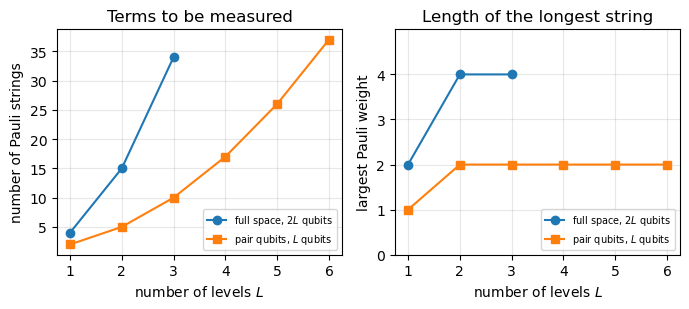

In [13]:
pair_levels = (1, 2, 3, 4, 5, 6)
pair_decompositions = {
    L: jordanwigner.decompose(jordanwigner.pairing_pair_qubits(L, g=1.0))
    for L in pair_levels
}


def summarise(decompositions):
    levels = sorted(decompositions)
    terms = [len(decompositions[L]) for L in levels]
    heaviest = [max(jordanwigner.weight(label)
                    for label in decompositions[L]) for L in levels]
    return levels, terms, heaviest


encodings = (
    ("full space, $2L$ qubits", full_decompositions, "o-"),
    ("pair qubits, $L$ qubits", pair_decompositions, "s-"),
)

fig, (left, right) = plt.subplots(1, 2, figsize=(7, 3.2))
for label, decompositions, style in encodings:
    levels, terms, heaviest = summarise(decompositions)
    left.plot(levels, terms, style, label=label)
    right.plot(levels, heaviest, style, label=label)

left.set_xlabel("number of levels $L$")
left.set_ylabel("number of Pauli strings")
left.set_title("Terms to be measured")
left.set_xticks(list(pair_levels))
left.grid(True, alpha=0.3)
left.legend(fontsize=7)

right.set_xlabel("number of levels $L$")
right.set_ylabel("largest Pauli weight")
right.set_title("Length of the longest string")
right.set_xticks(list(pair_levels))
right.set_yticks([0, 1, 2, 3, 4])
right.set_ylim(0, 5)
right.grid(True, alpha=0.3)
right.legend(fontsize=7, loc="lower right")

fig.tight_layout()
plt.show()
